In [1]:
import os

db_file = "sales_data.db"
if os.path.exists(db_file):
    os.remove(db_file)
    print(f"✅ Deleted old database: {db_file}")
else:
    print("ℹ️ No existing database found.")


ℹ️ No existing database found.


In [3]:
import sqlite3

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()
cursor.execute('''
CREATE TABLE sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')
conn.commit()
conn.close()
print("✅ New database and table created.")


✅ New database and table created.


In [5]:
import sqlite3

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

sales_data = [
    ("Laptop", 2, 50000),
    ("Mouse", 10, 500),
    ("Keyboard", 5, 1500),
    ("Monitor", 3, 12000),
    ("Mouse", 4, 500),
    ("Laptop", 1, 50000),
    ("Keyboard", 2, 1500)
]

cursor.executemany(
    "INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)",
    sales_data
)
conn.commit()
conn.close()
print("✅ New sample sales data inserted.")


✅ New sample sales data inserted.


In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("sales_data.db")
query = """
SELECT product,
       SUM(quantity)   AS total_qty,
       SUM(quantity*price) AS revenue
FROM sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)
conn.close()

print("📊 Sales Summary:\n")
print(df.to_string(index=False))


📊 Sales Summary:

 product  total_qty  revenue
Keyboard          7  10500.0
  Laptop          3 150000.0
 Monitor          3  36000.0
   Mouse         14   7000.0


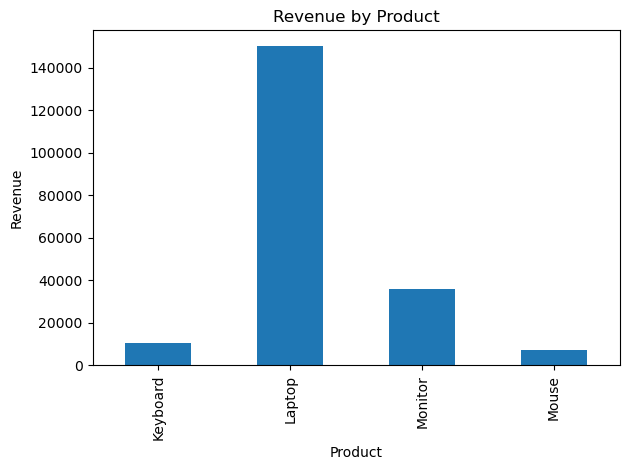

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Load data
conn = sqlite3.connect("sales_data.db")
df = pd.read_sql_query(
    "SELECT product, SUM(quantity*price) AS revenue FROM sales GROUP BY product",
    conn
)
conn.close()

# Plot
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', legend=False)
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()
